In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

In [39]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [40]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [41]:

df['age'].fillna(df['age'].median(), inplace=True)

df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df.drop(columns=['deck'], inplace=True)

C:\Users\arthi\AppData\Local\Temp\ipykernel_23516\2630737132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\arthi\AppData\Local\Temp\ipykernel_23516\2630737132.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [42]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

In [43]:
df['is_alone'] = np.where(df['family_size'] == 1, 1, 0)

In [44]:
bins = [0, 12, 20, 40, 60, 80]
labels = ['Child', 'Teen', 'Adult', 'Middle Age', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [45]:
df['fare_per_person'] = df['fare'] / df['family_size']

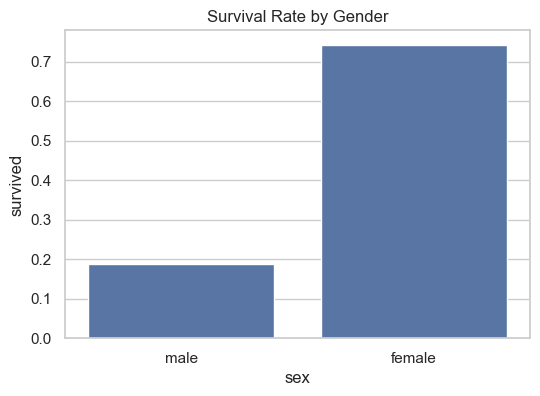

In [46]:
plt.figure(figsize=(6,4))
sns.barplot(x='sex', y='survived', data=df, errorbar=None)
plt.title("Survival Rate by Gender")
plt.show()

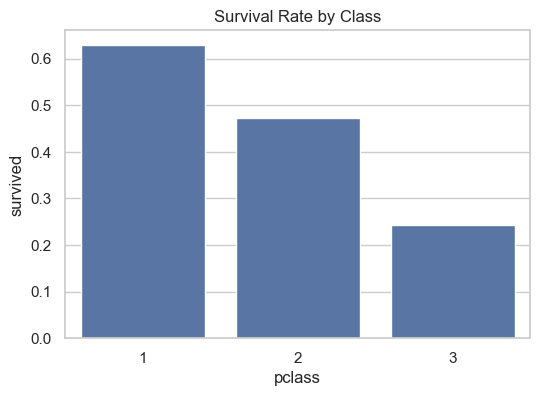

In [47]:
plt.figure(figsize=(6,4))
sns.barplot(x='pclass', y='survived', data=df, errorbar=None)
plt.title("Survival Rate by Class")
plt.show()

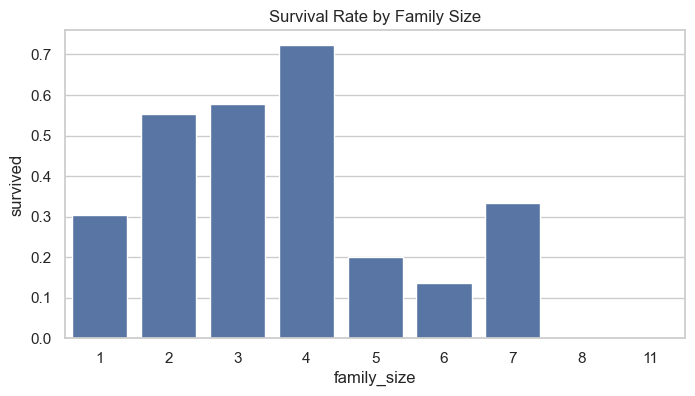

In [49]:
plt.figure(figsize=(8,4))
sns.barplot(x='family_size', y='survived', data=df, errorbar=None)
plt.title("Survival Rate by Family Size")
plt.show()

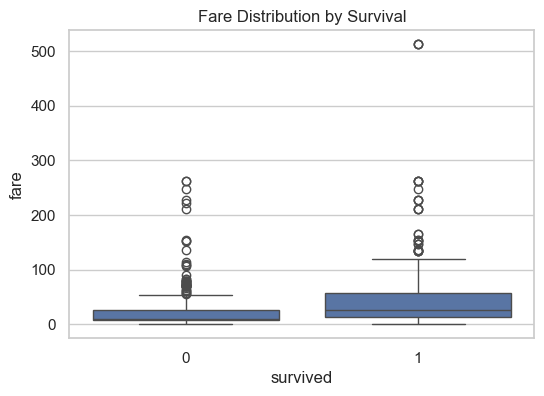

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(x='survived', y='fare', data=df)
plt.title("Fare Distribution by Survival")
plt.show()

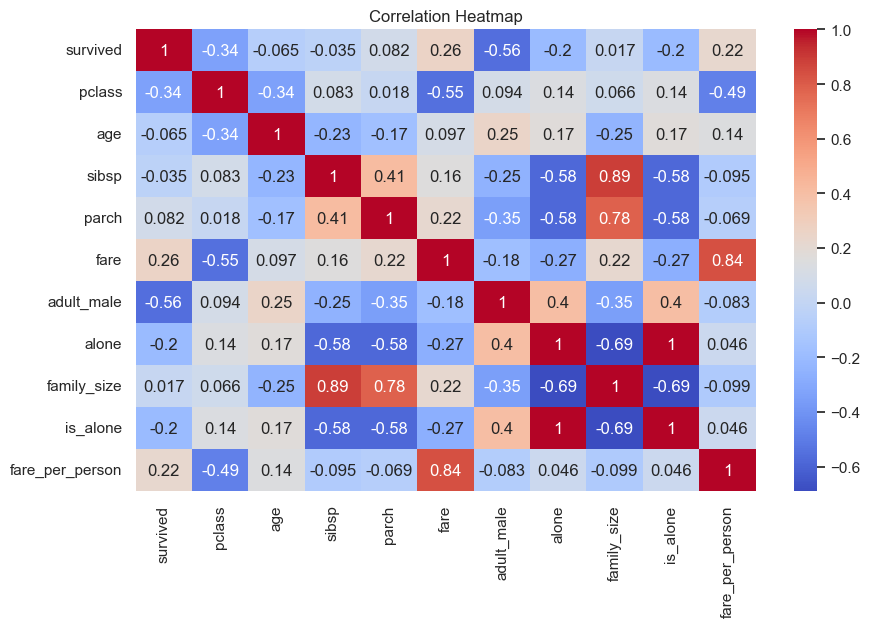

In [52]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [53]:
contingency_table = pd.crosstab(df['sex'], df['survived'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p)

Chi-square Statistic: 260.71702016732104
P-value: 1.1973570627755645e-58


In [54]:
survivors = df[df['survived'] == 1]['fare']
non_survivors = df[df['survived'] == 0]['fare']

t_stat, p_value = stats.ttest_ind(survivors, non_survivors)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 7.939191660871055
P-value: 6.120189341924198e-15


In [55]:
survivors_age = df[df['survived'] == 1]['age']
non_survivors_age = df[df['survived'] == 0]['age']

t_stat_age, p_age = stats.ttest_ind(survivors_age, non_survivors_age)

print("Age T-stat:", t_stat_age)
print("P-value:", p_age)

Age T-stat: -1.9394659179476366
P-value: 0.0527606884758555


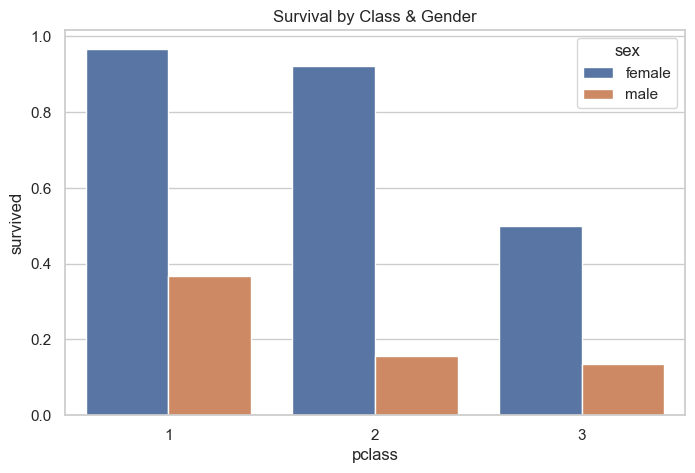

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(x='pclass', y='survived', hue='sex', data=df, errorbar=None)
plt.title("Survival by Class & Gender")
plt.show()

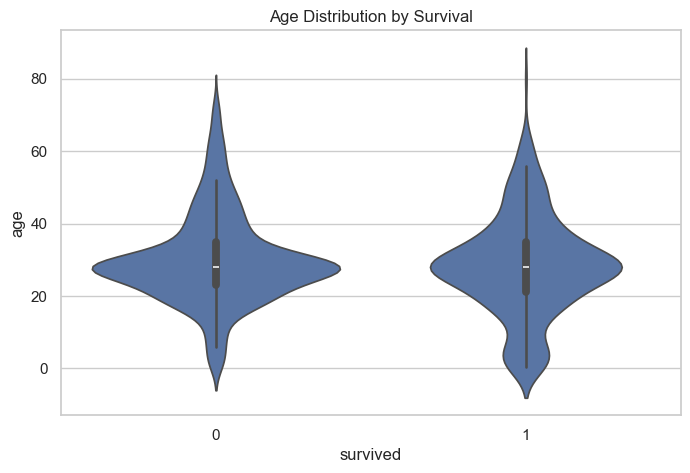

In [58]:
plt.figure(figsize=(8,5))
sns.violinplot(x='survived', y='age', data=df)
plt.title("Age Distribution by Survival")
plt.show()